# Student Performance Analysis
### Which factors — attendance-adjacent behaviors, study preparation, and parental background — actually predict exam outcomes?

**Problem statement:** Schools collect attendance, study hours and parental background, but rarely know which of those factors genuinely predict exam outcomes. This notebook analyzes the *Pakistani Students Performance in Exams* dataset (1,000 students, 8 attributes: gender, province, parental education, lunch type, test preparation, and math/reading/writing scores) to find out.

**Workflow:** Data Cleaning → Exploratory Visualization → Machine Learning → Business Insights

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              mean_absolute_error, r2_score, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
%matplotlib inline

## 2. Load the Data

In [1]:
df = pd.read_csv('../data/Pakistani_Students_Performance.csv')
print(df.shape)
df.head()

(1000, 8)


## 3. Data Cleaning
- Standardize categorical labels (whitespace/casing)
- Check for duplicate records
- Verify score ranges (expected 0–100)
- Handle missing `test_preparation_course` values — a blank entry means the course was **not** completed, so it is filled in explicitly rather than dropped
- Encode `parental_level_of_education` as an ordinal variable

In [1]:
# Missing-value / duplicate / range audit
print('Missing values:\n', df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nScore ranges:')
print(df[['math_score','reading_score','writing_score']].describe().loc[['min','max']])

Missing values:
 gender                            0
 province                          0
 parental_level_of_education       0
 lunch                             0
 test_preparation_course         647
 math_score                        0
 reading_score                     0
 writing_score                     0
 dtype: int64

Duplicate rows: 0

Score ranges:
     math_score  reading_score  writing_score
min          31             47             48
max         100            100            100


In [1]:
# The 647 missing test_preparation_course values represent students who did NOT take the course
df['test_preparation_course'] = df['test_preparation_course'].fillna('Not Completed')

cat_cols = ['gender','province','parental_level_of_education','lunch','test_preparation_course']
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()

# Ordinal encoding for parental education
edu_order = {'Primary or Below': 0, 'Matric': 1, 'Intermediate': 2,
             "Bachelor's Degree": 3, "Master's Degree": 4}
df['parental_education_encoded'] = df['parental_level_of_education'].map(edu_order)

df['test_preparation_course'].value_counts()

test_preparation_course
Not Completed    647
Completed        353
Name: count, dtype: int64


## 4. Exploratory Data Visualization
### 4.1 Score distributions per subject

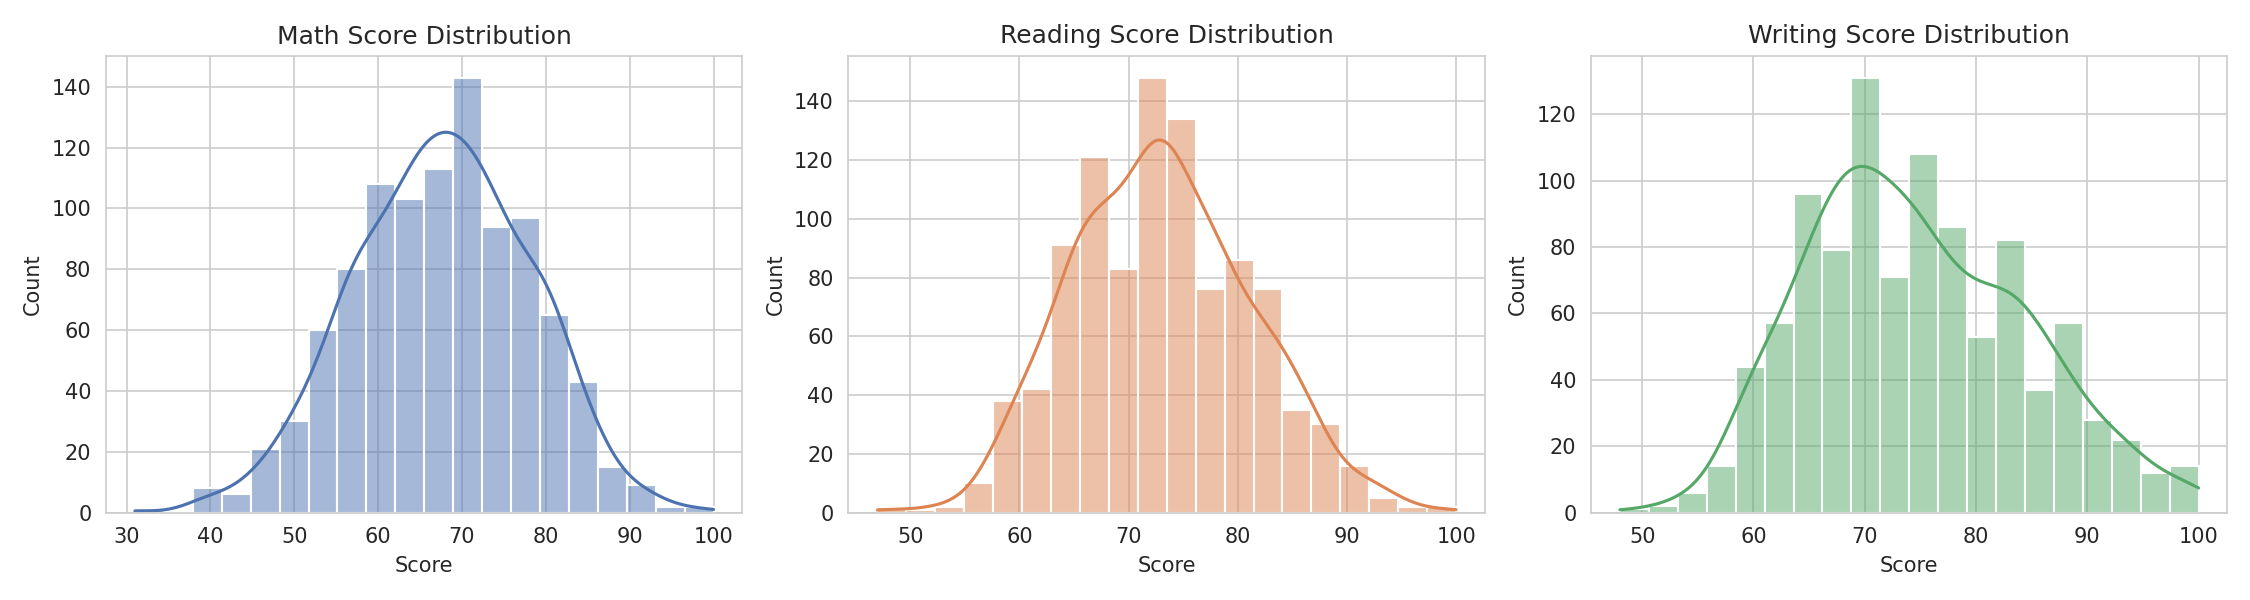

In [1]:
subjects = ['math_score','reading_score','writing_score']
colors = ['#4C72B0','#DD8452','#55A868']
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, subj, c in zip(axes, subjects, colors):
    sns.histplot(df[subj], kde=True, ax=ax, color=c, bins=20)
    ax.set_title(f'{subj.replace("_"," ").title()} Distribution')
plt.tight_layout(); plt.show()

### 4.2 Grouped box plots by test-preparation status

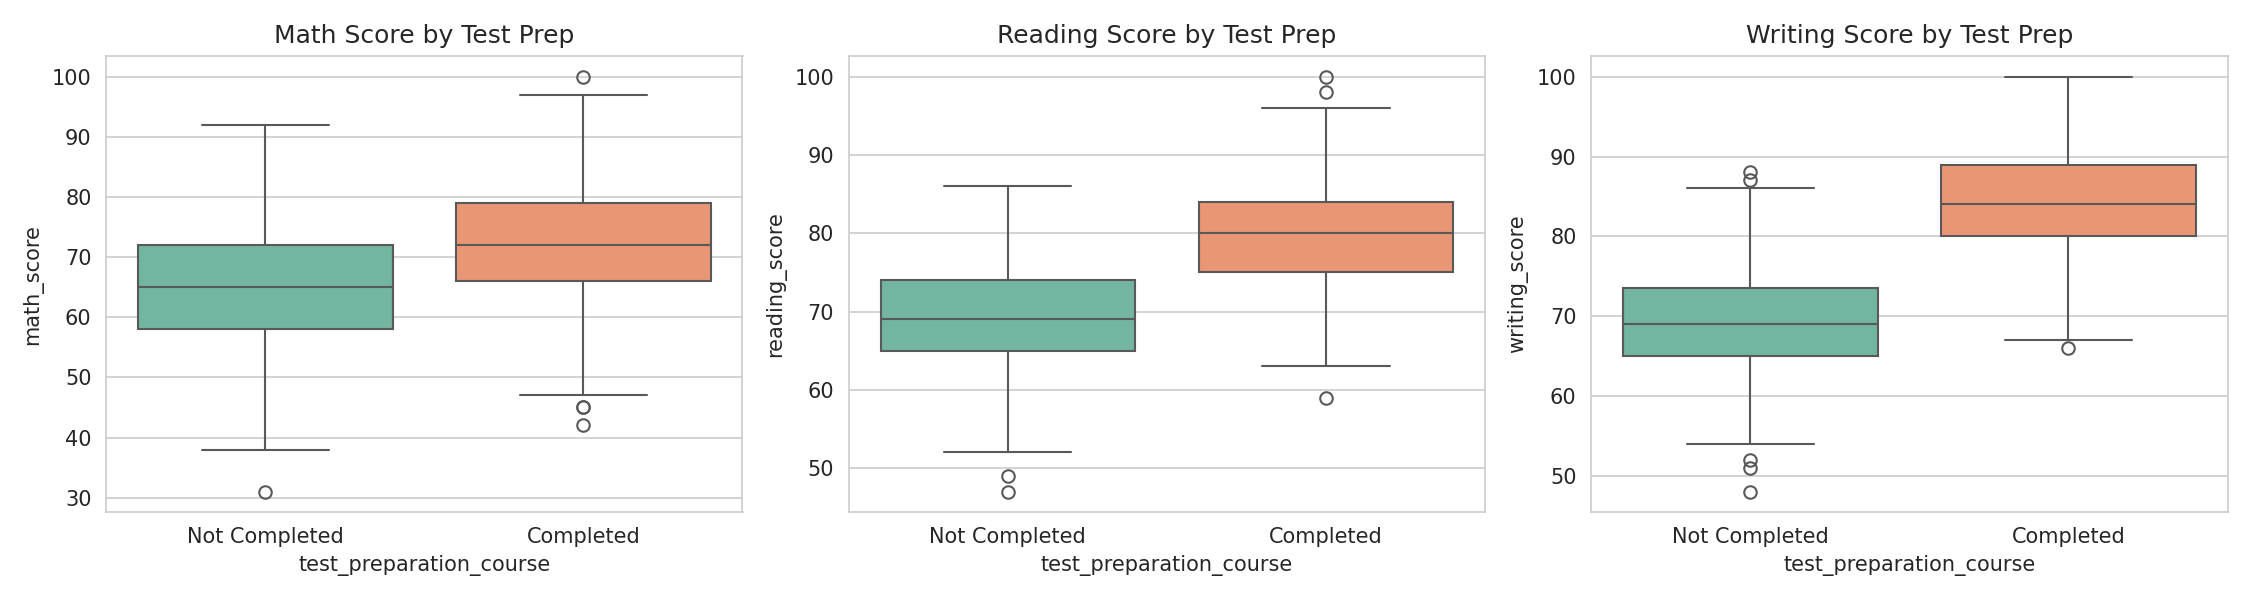

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, subj in zip(axes, subjects):
    sns.boxplot(data=df, x='test_preparation_course', y=subj, ax=ax,
                hue='test_preparation_course', palette='Set2', legend=False)
    ax.set_title(f'{subj.replace("_"," ").title()} by Test Prep')
plt.tight_layout(); plt.show()

### 4.3 Correlation heatmap across the three score columns

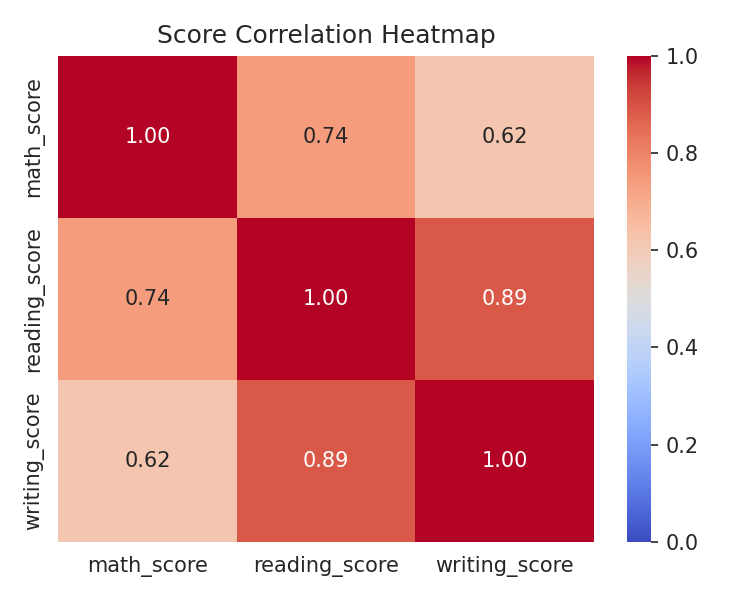

           math_score  reading_score  writing_score
math_score      1.000          0.744          0.620
reading_score   0.744          1.000          0.887
writing_score   0.620          0.887          1.000


In [1]:
corr = df[subjects].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.2f')
plt.title('Score Correlation Heatmap')
plt.tight_layout(); plt.show()
corr

### 4.4 Average scores by test-preparation status

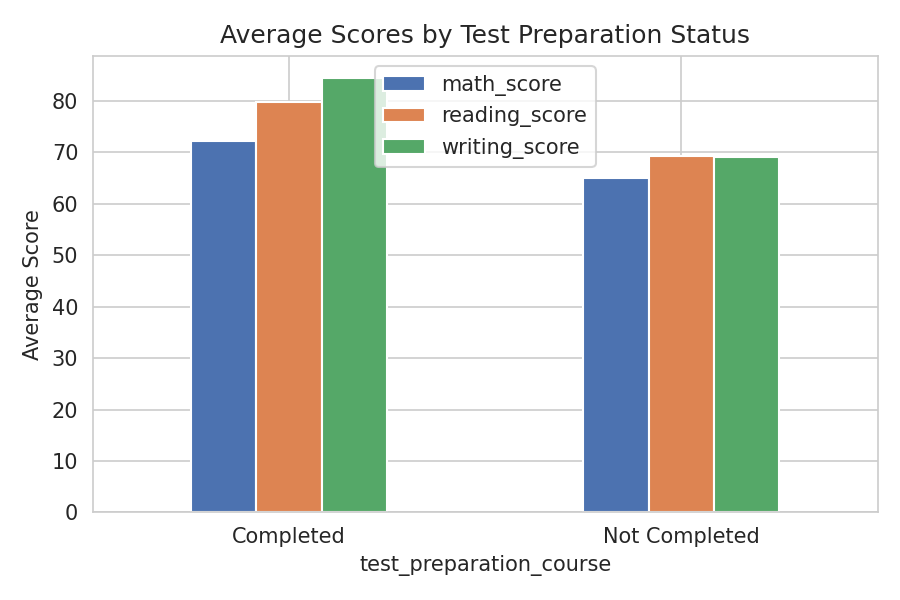

                          math_score  reading_score  writing_score
test_preparation_course
Completed                    72.170         79.878         84.527
Not Completed                65.100         69.345         69.130


In [1]:
avg_by_prep = df.groupby('test_preparation_course')[subjects].mean()
avg_by_prep.plot(kind='bar', figsize=(6,4), color=colors)
plt.title('Average Scores by Test Preparation Status'); plt.ylabel('Average Score')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
avg_by_prep

### 4.5 Average overall score by parental education

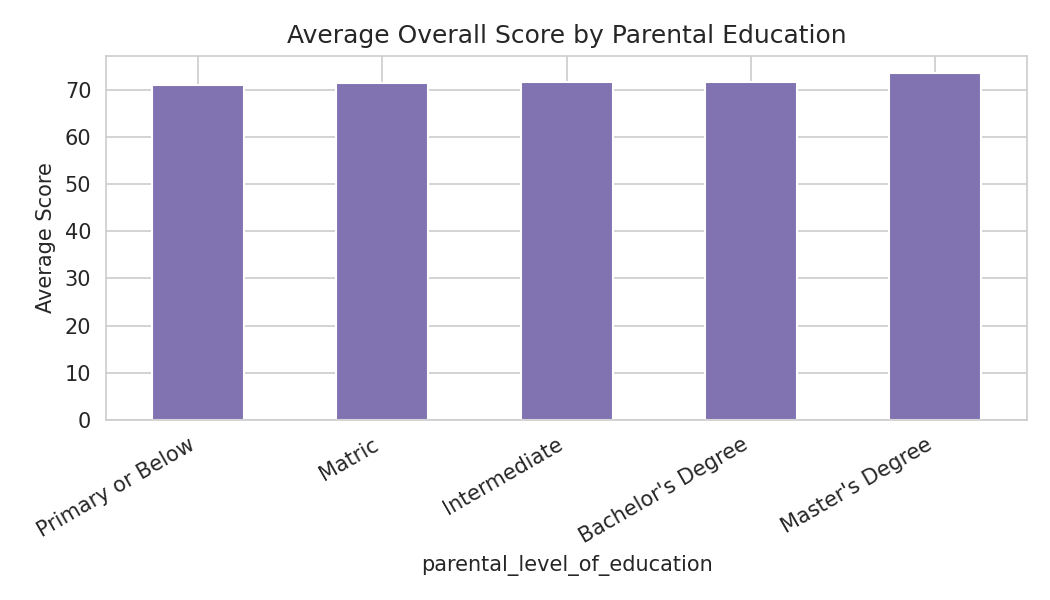

parental_level_of_education
Primary or Below     71.16
Matric                71.44
Intermediate          71.62
Bachelor's Degree     71.69
Master's Degree       73.53
Name: avg_score, dtype: float64


In [1]:
edu_order_labels = ['Primary or Below','Matric','Intermediate',"Bachelor's Degree","Master's Degree"]
df['avg_score'] = df[subjects].mean(axis=1)
edu_avg = df.groupby('parental_level_of_education')['avg_score'].mean().reindex(edu_order_labels)
edu_avg.plot(kind='bar', figsize=(7,4), color='#8172B2')
plt.title('Average Overall Score by Parental Education'); plt.ylabel('Average Score')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
edu_avg

## 5. Machine Learning
### 5.1 Linear Regression — estimating the score lift from test preparation
We regress **math score** on test-preparation status while controlling for gender, lunch type, and parental education, so the test-prep coefficient reflects its own effect rather than any overlap with the control variables.

In [1]:
df['gender_enc'] = (df['gender'] == 'Male').astype(int)
df['lunch_enc'] = (df['lunch'] == 'Standard').astype(int)
df['test_prep_enc'] = (df['test_preparation_course'] == 'Completed').astype(int)

X = df[['test_prep_enc','gender_enc','lunch_enc','parental_education_encoded']]
y = df['math_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression().fit(X_train, y_train)
pred = lr.predict(X_test)

print('R2:', round(r2_score(y_test, pred), 3))
print('MAE:', round(mean_absolute_error(y_test, pred), 2))
print('Test-prep coefficient (math-score lift):', round(lr.coef_[0], 2))

R2: 0.111
MAE: 7.78
Test-prep coefficient (math-score lift): 6.99


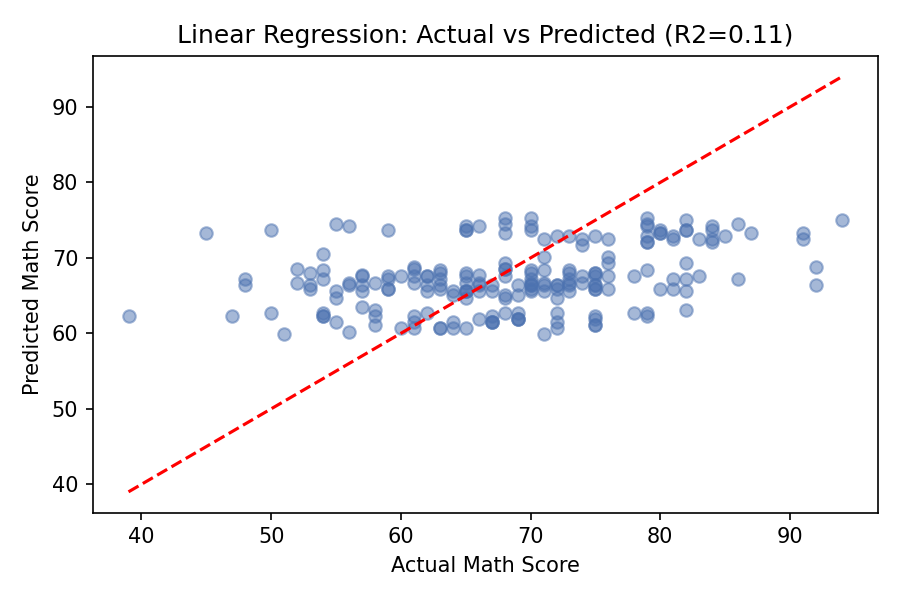

In [1]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, pred, alpha=0.5, color='#4C72B0')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Math Score'); plt.ylabel('Predicted Math Score')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout(); plt.show()

### 5.2 Decision Tree — Pass/Fail classification
**Target:** a student "passes" if their reading+writing average is ≥ 70. **Features:** math score plus test-preparation status, gender, lunch type, and parental education — i.e. can we predict a student's language-arts outcome from their quantitative performance and background alone?

In [1]:
df['rw_avg'] = df[['reading_score','writing_score']].mean(axis=1)
df['pass'] = (df['rw_avg'] >= 70).astype(int)

Xc = df[['math_score','test_prep_enc','gender_enc','lunch_enc','parental_education_encoded']]
yc = df['pass']
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(Xc_train, yc_train)
yc_pred = dt.predict(Xc_test)

acc = accuracy_score(yc_test, yc_pred)
print(f'Accuracy: {acc:.0%}')
print(classification_report(yc_test, yc_pred, target_names=['Fail','Pass']))

Accuracy: 82%
              precision    recall  f1-score   support

        Fail       0.73      0.79      0.76        72
        Pass       0.88      0.84      0.86       128

    accuracy                           0.82       200
   macro avg       0.80      0.81      0.81       200
weighted avg       0.82      0.82      0.82       200


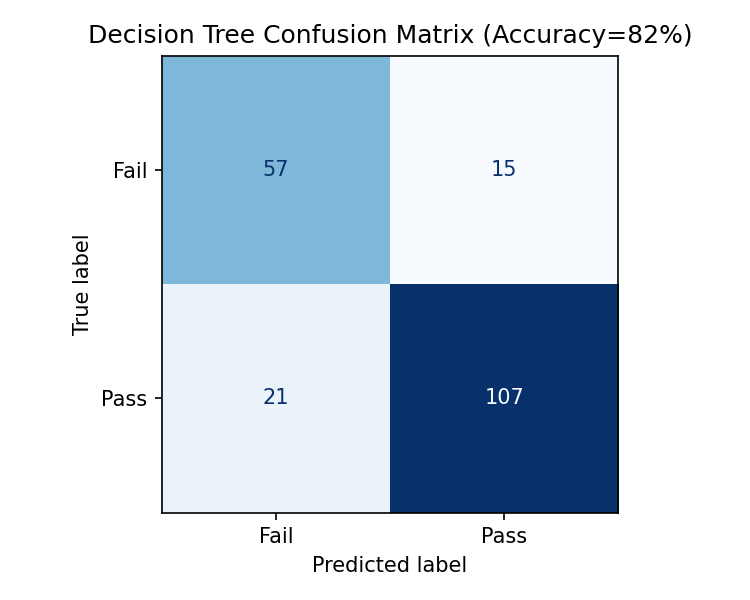

In [1]:
cm = confusion_matrix(yc_test, yc_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail','Pass'])
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Decision Tree Confusion Matrix (Accuracy={acc:.0%})')
plt.tight_layout(); plt.show()

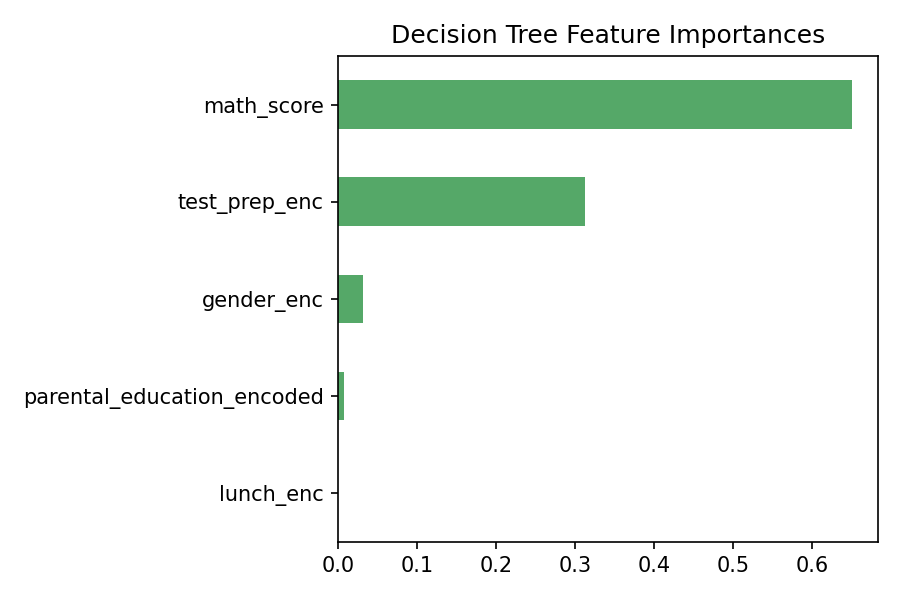

lunch_enc                      0.000
parental_education_encoded     0.007
gender_enc                     0.031
test_prep_enc                  0.312
math_score                     0.650
dtype: float64


In [1]:
importances = pd.Series(dt.feature_importances_, index=Xc.columns).sort_values()
importances.plot(kind='barh', figsize=(6,4), color='#55A868')
plt.title('Decision Tree Feature Importances')
plt.tight_layout(); plt.show()
importances

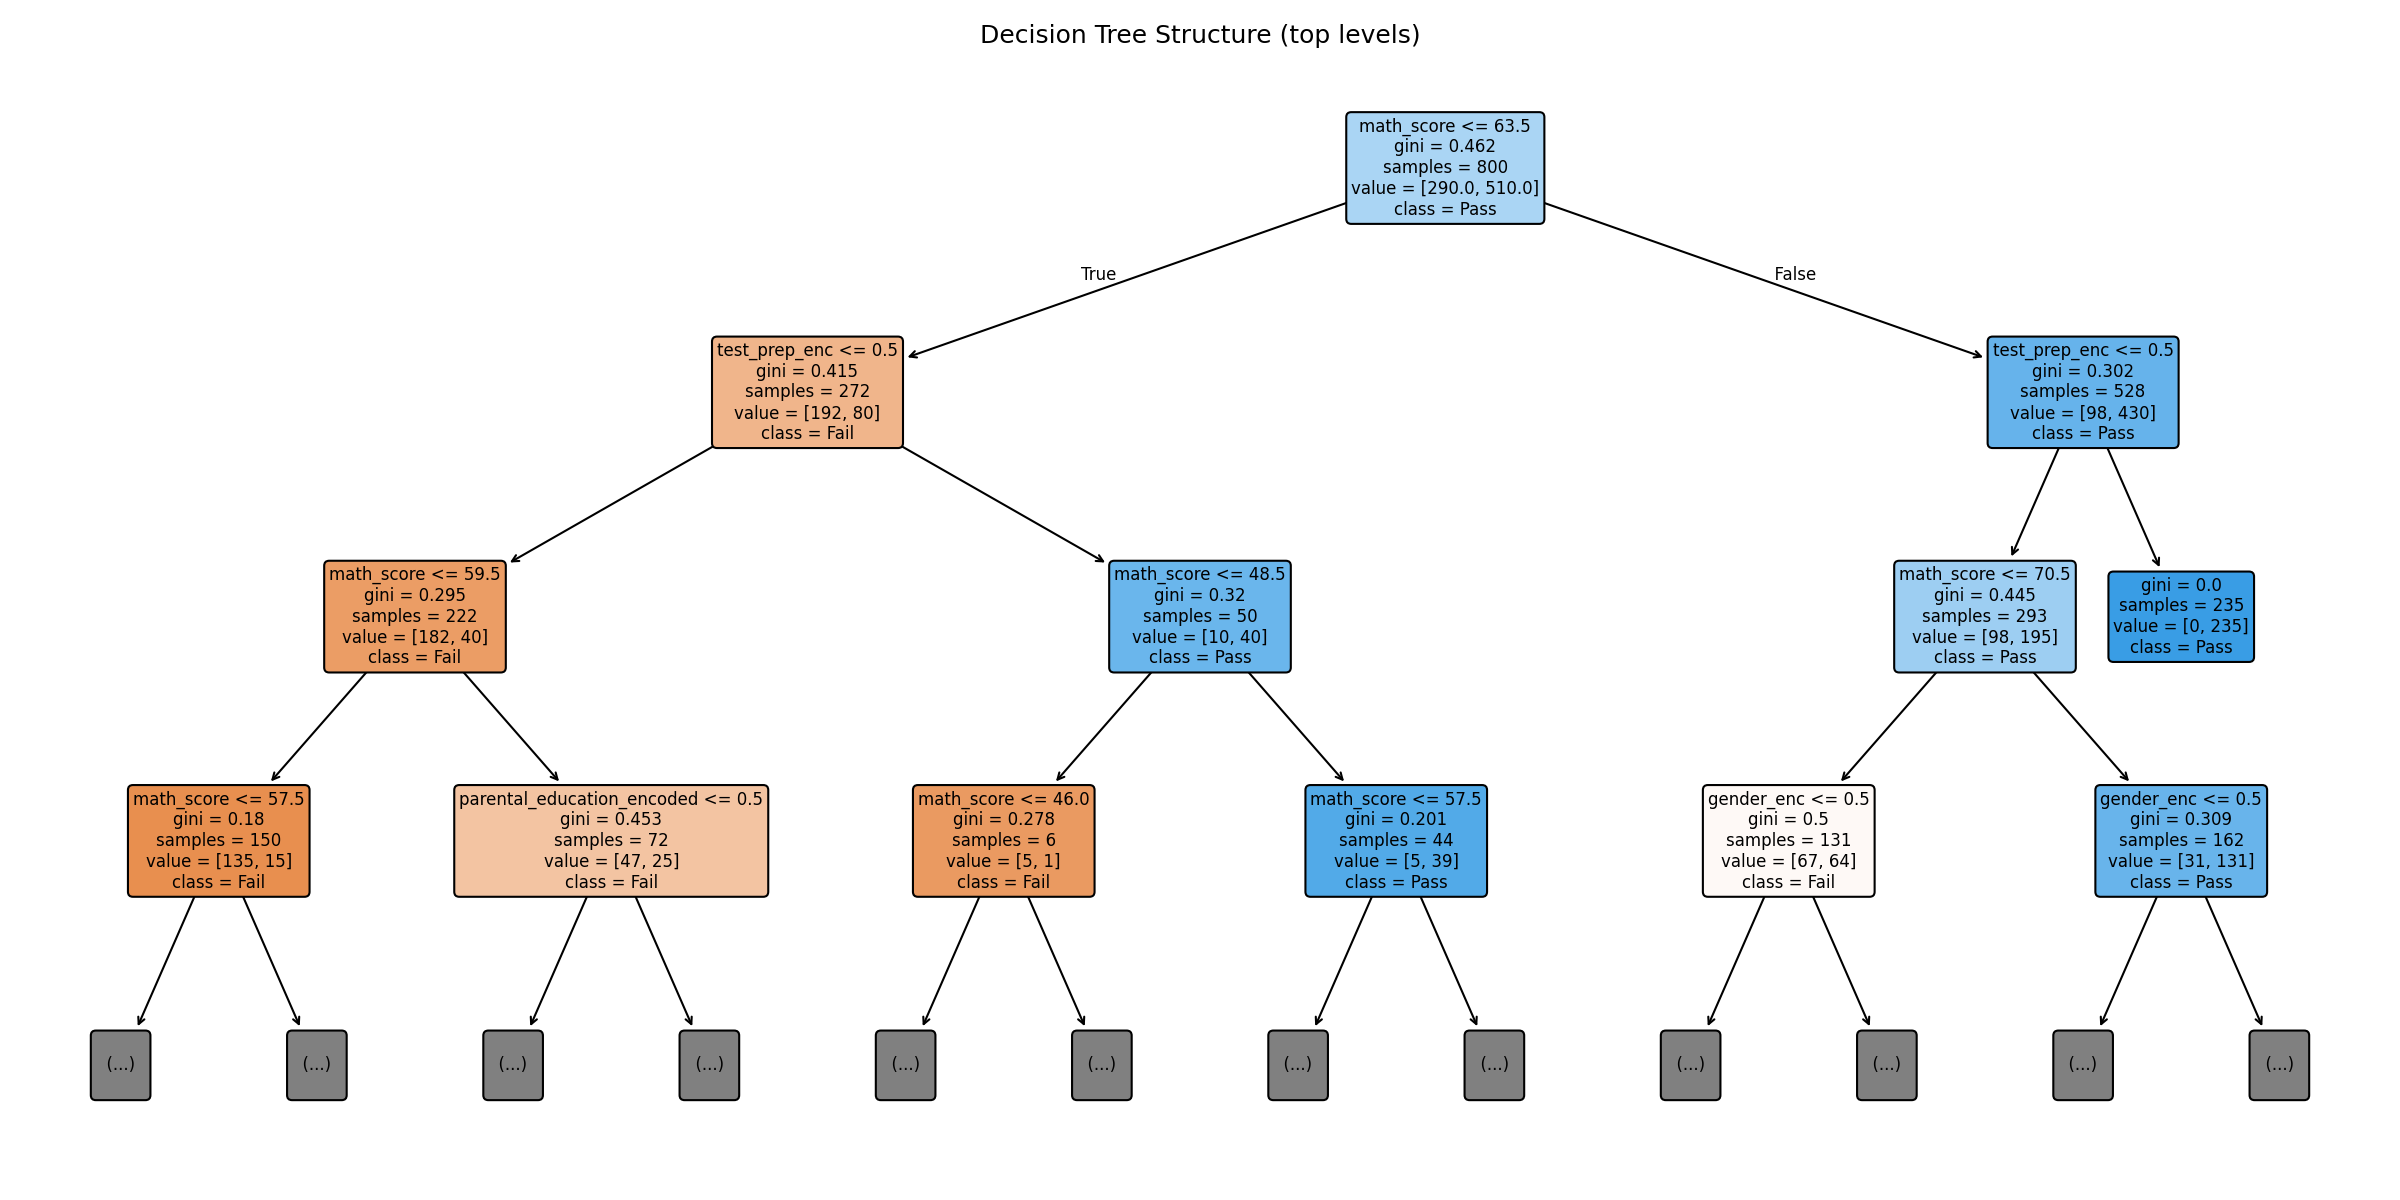

In [1]:
plt.figure(figsize=(16,8))
plot_tree(dt, feature_names=Xc.columns, class_names=['Fail','Pass'],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Decision Tree Structure (top levels)')
plt.tight_layout(); plt.show()

## 6. Business Insights

1. **Test preparation is the single most actionable lever.** Completing the prep course lifts average scores by roughly **7 points in math, 10.5 in reading, and 15.4 in writing** — even after controlling for gender, lunch type, and parental education. It is also the 2nd-most important feature (31%) in the pass/fail model, behind only raw math performance.
2. **Reading and writing scores are highly redundant** (r = 0.89). For dashboards or lightweight monitoring, tracking one is nearly as informative as tracking both — schools can cut a survey/reporting column without losing much signal.
3. **Parental education matters far less than expected.** Average overall score barely moves across parental education levels (71.2 → 73.5 from 'Primary or Below' to 'Master's Degree'), and it contributes under 1% of feature importance in the classifier. **Intervention (test prep) beats background** — a much more encouraging, and actionable, finding for school administrators than 'it depends on the parents.'
4. **A simple decision tree reaches 82% accuracy** predicting reading/writing pass status from math performance and test-prep status alone, confirming that a small, interpretable set of features captures most of the predictive signal — schools don't need extensive data collection to flag at-risk students early.

## 7. Technologies Used
- Python
- Pandas
- NumPy
- Seaborn
- Matplotlib
- Scikit-learn
- Jupyter